# CNN vs ViT Visualization Notebook

This notebook is meant to make the project easy to inspect visually.

It lets you:
- optionally run the experiment pipeline from inside the notebook
- inspect the saved JSON summaries
- display the saved plots and interpretability images
- preview clean, occluded, and texture-modified CIFAR-10 samples


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
INTERPRETABILITY_DIR = OUTPUT_DIR / "interpretability"

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs directory: {OUTPUT_DIR}")


Project root: /Users/macbookpro/Desktop/M2MIASD/S6/deep-learning/cnn-vit
Outputs directory: /Users/macbookpro/Desktop/M2MIASD/S6/deep-learning/cnn-vit/outputs


## Optional: Run the Experiment Pipeline

Set `RUN_EXPERIMENTS = True` if you want the notebook to launch the project for you.

If you already ran `uv run python main.py`, leave it as `False` and go straight to visualization.


In [2]:
from configs.config import build_config
from datasets.cifar_loader import describe_cifar_protocol

RUN_EXPERIMENTS = False
RUN_ARGS = []

config = build_config(full_run=("--full" in RUN_ARGS))

print("Planned dataset protocol:")
protocol = describe_cifar_protocol(config, fractions=config.experiment.data_fractions)
for run in protocol["runs"]:
    print(f"  - train split at {run['train_fraction']:.0%}: {run['train_size']} images")
print(f"  - validation split: {protocol['val_size']} images")
print(f"  - clean test split: {protocol['source_test_size']} images")
print(f"  - occluded test split: {protocol['source_test_size']} images")
print(f"  - texture-modified test split: {protocol['source_test_size']} images")

if RUN_EXPERIMENTS:
    command = ["uv", "run", "python", "main.py", *RUN_ARGS]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print("Skipping experiment execution. Set RUN_EXPERIMENTS = True to launch it from the notebook.")


Planned dataset protocol:
  - train split at 10%: 4500 images
  - train split at 25%: 11250 images
  - train split at 50%: 22500 images
  - train split at 100%: 45000 images
  - validation split: 5000 images
  - clean test split: 10000 images
  - occluded test split: 10000 images
  - texture-modified test split: 10000 images
Skipping experiment execution. Set RUN_EXPERIMENTS = True to launch it from the notebook.


## Load Saved Summary

In [3]:
def require(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing artifact: {path}. Run `uv run python main.py` first or set RUN_EXPERIMENTS = True above."
        )
    return path


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(str(row.get(column, "")) for column in columns) + " |")
    return "\n".join([header, separator, *body])


def fill_missing_split_sizes(rows, protocol):
    size_by_fraction = {
        run["train_fraction"]: {
            "train_size": run["train_size"],
            "val_size": run["val_size"],
            "test_size": run["clean_test_size"],
        }
        for run in protocol["runs"]
    }

    enriched_rows = []
    for row in rows:
        enriched = dict(row)
        fraction_sizes = size_by_fraction.get(row.get("train_fraction"), {})
        for key in ("train_size", "val_size", "test_size"):
            if enriched.get(key, "") in ("", None):
                enriched[key] = fraction_sizes.get(key, "")
        enriched_rows.append(enriched)
    return enriched_rows


def ensure_combined_comparison_plot(summary, output_path):
    if output_path.exists():
        return output_path

    histories = summary.get("full_run_histories", {})
    if not histories or not all(model in histories for model in ("cnn", "vit")):
        print(
            "Combined comparison plot is missing, and this summary.json does not contain saved histories. "
            "Run `uv run python main.py` again with the latest code if you want that new figure generated."
        )
        return None

    colors = {"cnn": "#1f4e79", "vit": "#b85c38"}
    figure, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
    for model_name in ("cnn", "vit"):
        history = histories[model_name]
        epochs = range(1, len(history["train_loss"]) + 1)
        color = colors[model_name]
        axes[0].plot(epochs, history["train_loss"], color=color, linewidth=2.3, marker="o", markersize=4.0, label=f"{model_name.upper()} train")
        axes[0].plot(epochs, history["val_loss"], color=color, linewidth=2.3, linestyle="--", marker="s", markersize=4.0, label=f"{model_name.upper()} val")
        axes[1].plot(epochs, history["train_accuracy"], color=color, linewidth=2.3, marker="o", markersize=4.0, label=f"{model_name.upper()} train")
        axes[1].plot(epochs, history["val_accuracy"], color=color, linewidth=2.3, linestyle="--", marker="s", markersize=4.0, label=f"{model_name.upper()} val")

    axes[0].set_title("Loss Comparison")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[1].set_title("Accuracy Comparison")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.0, 1.0)
    for axis in axes:
        axis.grid(True, axis="y", alpha=0.3)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.legend(loc="best")
    figure.suptitle("CNN vs ViT Learning Curves", fontsize=14)
    figure.tight_layout(rect=(0, 0, 1, 0.96))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=220)
    plt.close(figure)
    print(f"Generated missing combined comparison plot at: {output_path}")
    return output_path


summary_path = require(OUTPUT_DIR / "summary.json")
with summary_path.open("r", encoding="utf-8") as handle:
    summary = json.load(handle)
summary["data_efficiency"] = fill_missing_split_sizes(summary["data_efficiency"], protocol)

print(f"Loaded summary from: {summary_path}")


Loaded summary from: /Users/macbookpro/Desktop/M2MIASD/S6/deep-learning/cnn-vit/outputs/summary.json


In [4]:
display(Markdown("## Experiment Protocol and Dataset Sizes"))
display(
    Markdown(
        markdown_table(
            summary["data_efficiency"],
            ["model", "train_fraction", "train_size", "val_size", "test_size"],
        )
    )
)
display(
    Markdown(
        "The validation split stays fixed across runs. The occluded and texture-modified evaluations reuse the same test-set size as the clean CIFAR-10 test split."
    )
)

display(Markdown("## Baseline Results"))
display(
    Markdown(
        markdown_table(
            summary["baseline"],
            ["model", "train_fraction", "test_accuracy", "best_val_accuracy", "parameter_count", "training_time_readable"],
        )
    )
)

display(Markdown("## Robustness Results"))
display(
    Markdown(
        markdown_table(
            summary["robustness"],
            ["model", "shift", "clean_accuracy", "shifted_accuracy", "robustness_drop"],
        )
    )
)

display(Markdown("## Data Efficiency Results"))
display(
    Markdown(
        markdown_table(
            summary["data_efficiency"],
            ["model", "train_fraction", "train_size", "val_size", "test_size", "test_accuracy", "best_val_accuracy", "training_time_readable"],
        )
    )
)


## Experiment Protocol and Dataset Sizes

| model | train_fraction | train_size | val_size | test_size |
| --- | --- | --- | --- | --- |
| cnn | 0.1 | 4500 | 5000 | 10000 |
| cnn | 0.25 | 11250 | 5000 | 10000 |
| cnn | 0.5 | 22500 | 5000 | 10000 |
| cnn | 1.0 | 45000 | 5000 | 10000 |
| vit | 0.1 | 4500 | 5000 | 10000 |
| vit | 0.25 | 11250 | 5000 | 10000 |
| vit | 0.5 | 22500 | 5000 | 10000 |
| vit | 1.0 | 45000 | 5000 | 10000 |

The validation split stays fixed across runs. The occluded and texture-modified evaluations reuse the same test-set size as the clean CIFAR-10 test split.

## Baseline Results

| model | train_fraction | test_accuracy | best_val_accuracy | parameter_count | training_time_readable |
| --- | --- | --- | --- | --- | --- |
| cnn | 1.0 | 0.5909 | 0.5874 | 374282 | 3m 59s |
| vit | 1.0 | 0.5328 | 0.5266 | 1803850 | 9m 06s |

## Robustness Results

| model | shift | clean_accuracy | shifted_accuracy | robustness_drop |
| --- | --- | --- | --- | --- |
| cnn | occluded | 0.5909 | 0.5377 | 0.053200000000000025 |
| cnn | texture | 0.5909 | 0.3167 | 0.2742 |
| vit | occluded | 0.5328 | 0.5034 | 0.029400000000000093 |
| vit | texture | 0.5328 | 0.4117 | 0.12110000000000004 |

## Data Efficiency Results

| model | train_fraction | train_size | val_size | test_size | test_accuracy | best_val_accuracy | training_time_readable |
| --- | --- | --- | --- | --- | --- | --- | --- |
| cnn | 0.1 | 4500 | 5000 | 10000 | 0.4769 | 0.4782 | 2m 48s |
| cnn | 0.25 | 11250 | 5000 | 10000 | 0.5396 | 0.5414 | 2m 57s |
| cnn | 0.5 | 22500 | 5000 | 10000 | 0.5251 | 0.5324 | 3m 17s |
| cnn | 1.0 | 45000 | 5000 | 10000 | 0.5909 | 0.5874 | 3m 59s |
| vit | 0.1 | 4500 | 5000 | 10000 | 0.3406 | 0.316 | 3m 21s |
| vit | 0.25 | 11250 | 5000 | 10000 | 0.407 | 0.4024 | 4m 18s |
| vit | 0.5 | 22500 | 5000 | 10000 | 0.4685 | 0.4594 | 5m 54s |
| vit | 1.0 | 45000 | 5000 | 10000 | 0.5328 | 0.5266 | 9m 06s |

## Image Display Helpers

In [5]:
def show_images(image_paths, titles=None, cols=2, figsize=(14, 8)):
    image_paths = [Path(path) for path in image_paths]
    available_items = []
    missing_items = []

    for index, path in enumerate(image_paths):
        title = titles[index] if titles else path.name
        if path.exists():
            available_items.append((path, title))
        else:
            missing_items.append((path, title))

    if missing_items:
        print("Skipping missing plot artifacts:")
        for path, title in missing_items:
            print(f"  - {title}: {path}")

    if not available_items:
        print("No requested images are available yet.")
        return

    rows = (len(available_items) + cols - 1) // cols
    figure, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for index, (path, title) in enumerate(available_items):
        image = mpimg.imread(path)
        axes[index].imshow(image)
        axes[index].set_title(title)
        axes[index].axis("off")

    for index in range(len(available_items), len(axes)):
        axes[index].axis("off")

    plt.tight_layout()
    plt.show()


## Training and Evaluation Plots

Combined comparison plot is missing, and this summary.json does not contain saved histories. Run `uv run python main.py` again with the latest code if you want that new figure generated.
Skipping missing plot artifacts:
  - CNN vs ViT combined learning curves: /Users/macbookpro/Desktop/M2MIASD/S6/deep-learning/cnn-vit/outputs/plots/cnn_vit_training_comparison.png


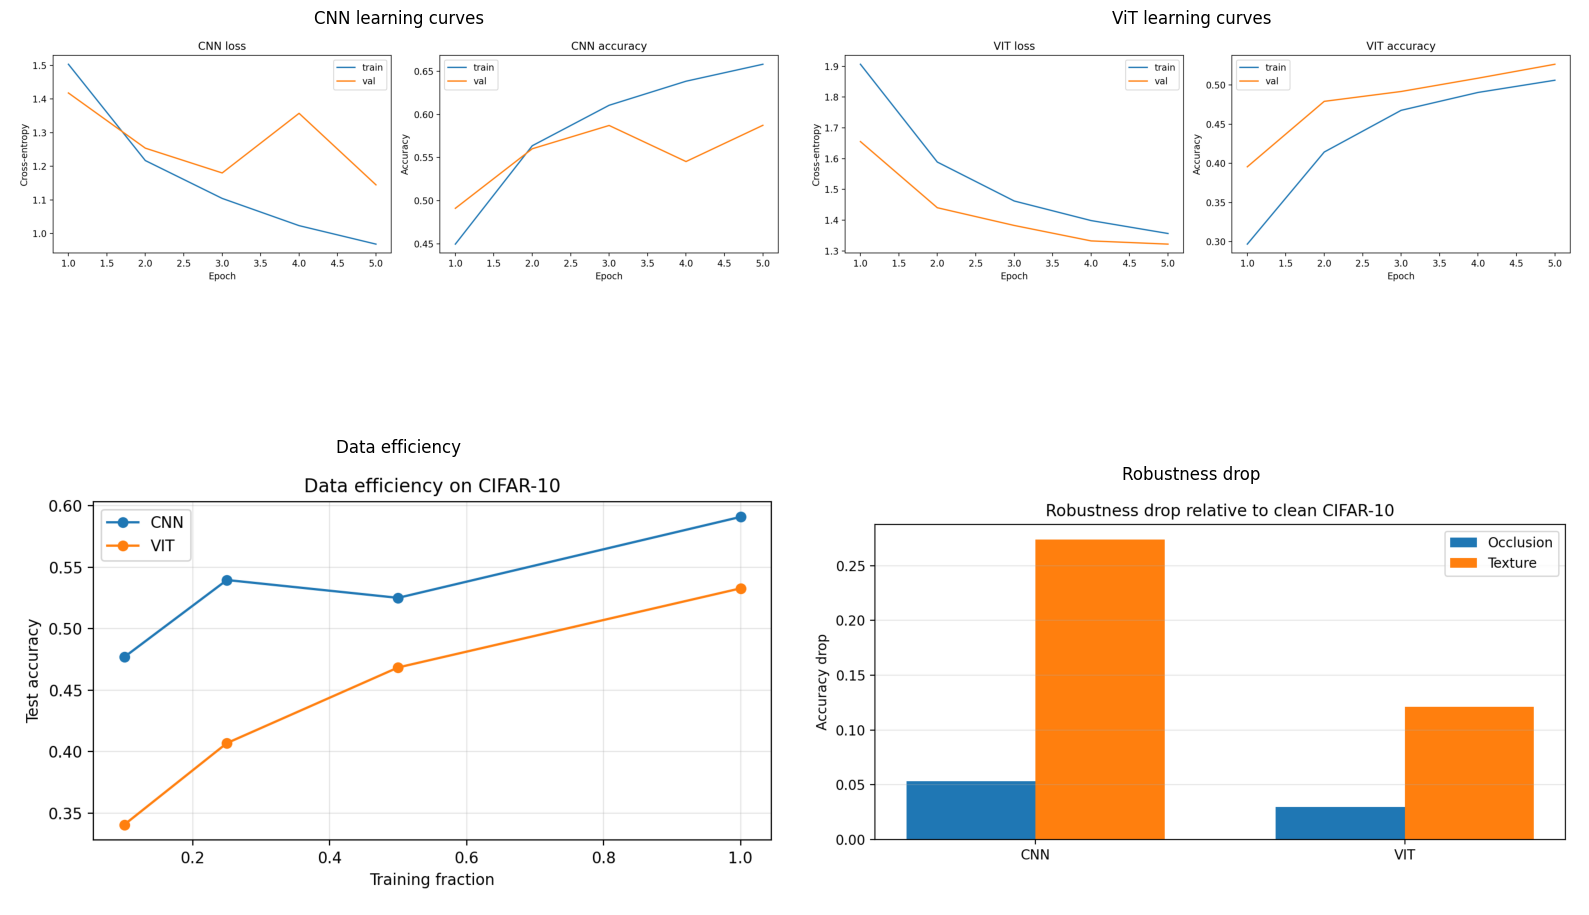

In [6]:
ensure_combined_comparison_plot(summary, PLOTS_DIR / "cnn_vit_training_comparison.png")

show_images(
    [
        PLOTS_DIR / "cnn_vit_training_comparison.png",
        PLOTS_DIR / "cnn_training_curves.png",
        PLOTS_DIR / "vit_training_curves.png",
        PLOTS_DIR / "data_efficiency.png",
        PLOTS_DIR / "robustness_drop.png",
    ],
    titles=[
        "CNN vs ViT combined learning curves",
        "CNN learning curves",
        "ViT learning curves",
        "Data efficiency",
        "Robustness drop",
    ],
    cols=2,
    figsize=(16, 12),
)


## Interpretability Images

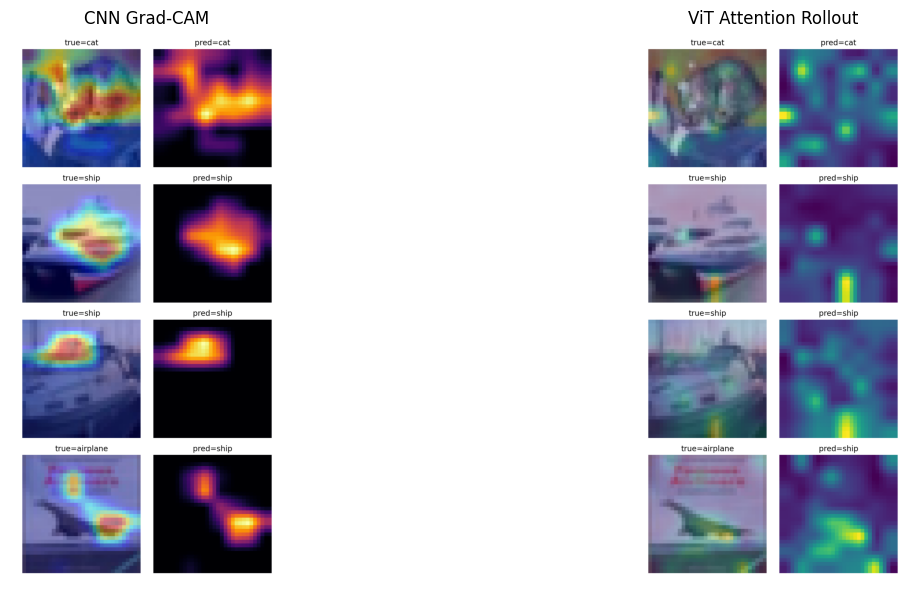

In [7]:
show_images(
    [
        INTERPRETABILITY_DIR / "cnn_gradcam.png",
        INTERPRETABILITY_DIR / "vit_attention.png",
    ],
    titles=["CNN Grad-CAM", "ViT Attention Rollout"],
    cols=2,
    figsize=(16, 6),
)


## Preview Clean vs Occluded vs Texture-Modified CIFAR-10 Samples

This section rebuilds the dataset transforms so you can visually inspect what the robustness test data looks like.


In [8]:
from configs.config import build_config
from datasets.cifar_loader import build_cifar_datasets
from datasets.occlusion import OcclusionWrapperDataset
from datasets.texture_modification import TextureModifiedDataset
from utils.helpers import to_numpy_image

config = build_config()

_, _, clean_test_dataset, class_names = build_cifar_datasets(
    config=config,
    train_fraction=1.0,
    test_variant="clean",
)

occluded_test_dataset = OcclusionWrapperDataset(
    clean_test_dataset,
    mask_size=config.augmentations.occlusion_mask_size,
    fill_value=config.augmentations.occlusion_fill_value,
    seed=config.training.seed,
)

texture_test_dataset = TextureModifiedDataset(
    clean_test_dataset,
    patch_size=config.augmentations.texture_patch_size,
    shuffle_fraction=config.augmentations.texture_shuffle_fraction,
    noise_std=config.augmentations.texture_noise_std,
    seed=config.training.seed,
)

print(f"Loaded {len(clean_test_dataset)} clean CIFAR-10 test images.")


Loaded 10000 clean CIFAR-10 test images.


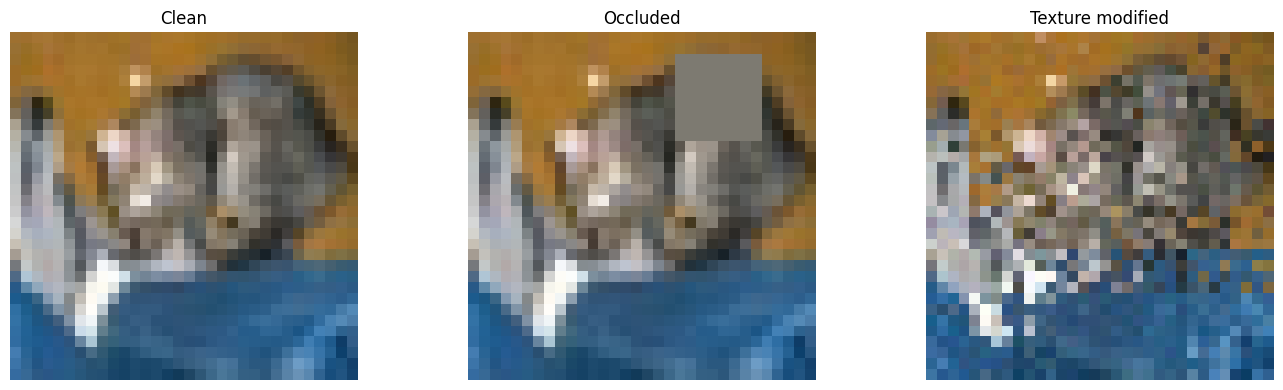

Sample index: 0
Class label: cat


In [9]:
sample_index = 0

clean_image, label = clean_test_dataset[sample_index]
occluded_image, _ = occluded_test_dataset[sample_index]
texture_image, _ = texture_test_dataset[sample_index]

figure, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(to_numpy_image(clean_image, config.data.mean, config.data.std))
axes[0].set_title("Clean")
axes[0].axis("off")

axes[1].imshow(to_numpy_image(occluded_image, config.data.mean, config.data.std))
axes[1].set_title("Occluded")
axes[1].axis("off")

axes[2].imshow(to_numpy_image(texture_image, config.data.mean, config.data.std))
axes[2].set_title("Texture modified")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Sample index: {sample_index}")
print(f"Class label: {class_names[label]}")
